In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../3.1 UNZIP_ME_FOR_NOTEBOOKS_V4/DATA/Advertising.csv')

In [6]:
X = df.drop('sales',axis=1)
y = df['sales']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

In [ ]:
train_predictions_errors = []

test_predictions_errors = []

for n in range(1,10):
    poly_conv = PolynomialFeatures(degree=n)
    X_conv=poly_conv.fit_transform(X)
    

    X_train, X_test, y_train, y_test = train_test_split(X_conv, y, test_size=0.3, random_state=101)

    lr_model = LinearRegression()

    train_pred = lr_model.fit(X_train,y_train).predict(X_train)
    test_pred = lr_model.predict(X_test)

    train_error = np.sqrt(mean_squared_error(train_pred,y_train))
    test_error = np.sqrt(mean_squared_error(test_pred,y_test))

    train_predictions_errors.append(train_error)
    test_predictions_errors.append(test_error)

    

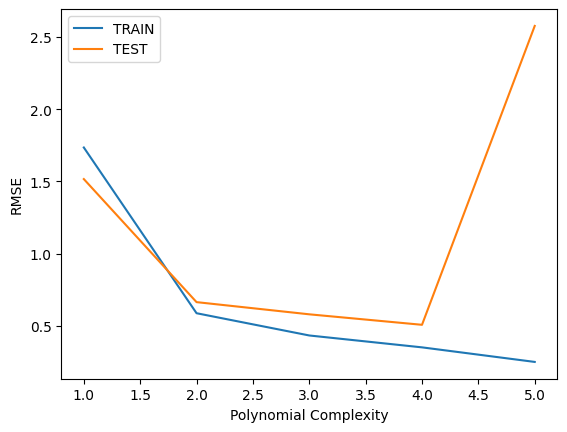

In [11]:
plt.plot(range(1,6),train_predictions_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_predictions_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

In [12]:
from joblib import dump,load